# Local Quadratic Tradeoff Model — Pareto Front Analysis

This notebook demonstrates the local quadratic tradeoff model on an example Pareto front.

For each point on the front the model fits a local quadratic regression of each objective
on all others using k nearest neighbours. The linear coefficient at any query point gives
the **Marginal Rate of Substitution (MRS)**:

$$\mathrm{MRS}(i \to j;\, \mathbf{p}) = \hat{\beta}_{j \leftarrow i} \cdot \frac{\mathrm{IQR}_i}{\mathrm{IQR}_j}$$

**Interpretation:** a 1% improvement in objective $i$ (relative to its IQR) is associated
with an MRS% change in objective $j$ (relative to its IQR).
- Negative = tradeoff (improving $i$ worsens $j$)
- Positive = synergy (improving $i$ also improves $j$)


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.ndimage import uniform_filter1d
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import PolynomialFeatures

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


Extract pareto fronts

In [2]:
import pickle
from pathlib import Path
import pandas as pd

RUNS_DIR = Path("data/eda_results/sol_reweight_runs")
OUT_DIR = Path("data/pf")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OBJ_COLS = [f"o{i}" for i in range(1, 6)]
pkl_files = sorted(RUNS_DIR.glob("eda_human_reweight_*.pkl"))
print(f"Found {len(pkl_files)} run pickle(s) in {RUNS_DIR}")
saved = []
for pkl_path in pkl_files:
    with open(pkl_path, "rb") as f:
        results = pickle.load(f)
    pf = results["converged_pf_table"][-1]
    df = pd.DataFrame(pf, columns=OBJ_COLS).astype(int)
    # Match reference CSV naming: drop the eda_human_reweight_ prefix
    out_name = pkl_path.stem.replace("eda_human_reweight_", "", 1) + ".csv"
    out_path = OUT_DIR / out_name
    df.to_csv(out_path, index=False)
    saved.append((out_path.name, len(df)))
print(f"Saved {len(saved)} CSV(s) to {OUT_DIR.resolve()}")
for name, n in saved[:5]:
    print(f"  {name}: {n} points")
if len(saved) > 5:
    print(f"  ... and {len(saved) - 5} more")

Found 260 run pickle(s) in data/eda_results/sol_reweight_runs
Saved 260 CSV(s) to /home/tailai/multiobjective/data/pf
  refq25_temp0.1_trial10.csv: 1081 points
  refq25_temp0.1_trial8.csv: 971 points
  refq25_temp0.2_trial10.csv: 1613 points
  refq25_temp0.2_trial8.csv: 2066 points
  refq25_temp0.3_trial10.csv: 2902 points
  ... and 255 more


## Parameters

In [ ]:
CSV_PATH   = "eda_human_minmax_95_5_prank_3.csv"  # path to your Pareto front CSV

K          = 100     # nearest neighbours for local regression
SMOOTH     = 80      # moving average window for line plots
EPSILON    = 0.10    # error tolerance for validity radius (0.10 = 10%)

# Query point: set as percentiles (0-100 per objective), or None for median
# PERCENTILE = [75, 75, 75, 25, 25]  #means 75th percentile of each objective
PERCENTILE = None    # None = median (50th percentile of each objective)

# Fixed colour per objective — consistent across all plots
OBJ_COLORS = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#B07AA1"]


## Load Data

In [3]:
df        = pd.read_csv(CSV_PATH)
data      = df.values.astype(float)
obj_names = list(df.columns)
N, d      = data.shape

iqr   = np.percentile(data, 75, axis=0) - np.percentile(data, 25, axis=0)
nadir = data.min(axis=0)
ideal = data.max(axis=0)

print(f"Objectives : {obj_names}")
print(f"Points     : {N:,}")
print(f"\nPer-objective summary:")
summary = pd.DataFrame({
    'min':    nadir.round(1),
    'median': np.median(data, axis=0).round(1),
    'max':    ideal.round(1),
    'IQR':    iqr.round(2),
}, index=obj_names)
display(summary)


Objectives : ['o1', 'o2', 'o3', 'o4', 'o5']
Points     : 3,060

Per-objective summary:


,min,median,max,IQR
o1,47.0,94.0,133.0,20.25
o2,36.0,78.0,117.0,18.00
o3,59.0,118.0,151.0,19.00
o4,38.0,80.0,131.0,22.00
o5,37.0,76.0,123.0,19.00


## Query Point

In [4]:
if PERCENTILE is not None:
    target      = np.array([np.percentile(data[:, i], p)
                            for i, p in enumerate(PERCENTILE)])
    query_label = "percentile"
    print("Target (percentile):")
    for n, p, v in zip(obj_names, PERCENTILE, target):
        print(f"  {n}: {p:.0f}th → {v:.1f}")
else:
    target      = np.median(data, axis=0)
    query_label = "median"
    print("Target (median):")
    for n, v in zip(obj_names, target):
        print(f"  {n}: {v:.1f}")

dists     = np.abs((data - target) / iqr).sum(axis=1)
query_idx = int(np.argmin(dists))
query_pt  = data[query_idx]

print(f"\nNearest front point (index {query_idx}):")
for n, v in zip(obj_names, query_pt):
    print(f"  {n}: {v:.1f}")


Target (percentile):
  o1: 75th → 103.2
  o2: 75th → 87.0
  o3: 75th → 127.0
  o4: 25th → 70.0
  o5: 25th → 67.0

Nearest front point (index 2486):
  o1: 106.0
  o2: 88.0
  o3: 126.0
  o4: 70.0
  o5: 67.0


## Compute MRS Across All Points

In [5]:
poly = PolynomialFeatures(degree=2, include_bias=True)

print(f"Building {K}-NN graph ...", end=" ", flush=True)
t0 = time.time()
nn = NearestNeighbors(n_neighbors=K + 1).fit(data / iqr)
_, nn_indices = nn.kneighbors(data / iqr) # nn_indices has shape (N, K+1)
print(f"{time.time()-t0:.1f}s")

print(f"Fitting local quadratic regressions at {N:,} points ...", end=" ", flush=True)
t0    = time.time()
betas = np.zeros((N, d, d))

for idx in range(N):
    nbrs = data[nn_indices[idx, 1:]] - data[idx] # nbrs has shape (K, d)
    for j in range(d):
        input_cols = [c for c in range(d) if c != j]
        X_poly     = poly.fit_transform(nbrs[:, input_cols]) # X_poly is the design matrix
        coef, _, _, _ = np.linalg.lstsq(X_poly, nbrs[:, j], rcond=None) # for d = 5, X_poly is (K, 15), nbrs[:, j] is (K, ), coef is (15, )
        for pos, i in enumerate(input_cols):
            betas[idx, i, j] = coef[pos + 1] * iqr[i] / iqr[j] # only linear coef are extraced for MRS

print(f"{time.time()-t0:.1f}s")
print("Done.")


Building 100-NN graph ... 0.1s
Fitting local quadratic regressions at 3,060 points ... 1.7s
Done.


## MRS Summary Tables

In [6]:
# MRS at query point
print(f"MRS at {query_label} point  (index {query_idx}):")
df_query = pd.DataFrame(betas[query_idx], index=obj_names, columns=obj_names)
np.fill_diagonal(df_query.values, np.nan)
display(df_query.round(3))

# Mean MRS across all points
print(f"\nMean MRS across all {N:,} points:")
df_mean = pd.DataFrame(betas.mean(axis=0), index=obj_names, columns=obj_names)
np.fill_diagonal(df_mean.values, np.nan)
display(df_mean.round(3))


MRS at percentile point  (index 2486):


,o1,o2,o3,o4,o5
o1,NaN,-0.963,-1.239,-1.004,-1.438
o2,-0.560,NaN,-1.035,-0.674,-0.880
o3,-0.361,-0.555,NaN,-0.530,-0.819
o4,-0.719,-0.798,-1.159,NaN,-0.996
o5,-0.537,-0.617,-0.829,-0.609,NaN



Mean MRS across all 3,060 points:


,o1,o2,o3,o4,o5
o1,NaN,-0.836,-0.789,-0.741,-0.850
o2,-0.549,NaN,-0.540,-0.545,-0.596
o3,-0.413,-0.427,NaN,-0.401,-0.511
o4,-0.805,-0.906,-0.834,NaN,-0.881
o5,-0.506,-0.554,-0.614,-0.490,NaN


## Line Plots — MRS Across the Full Front

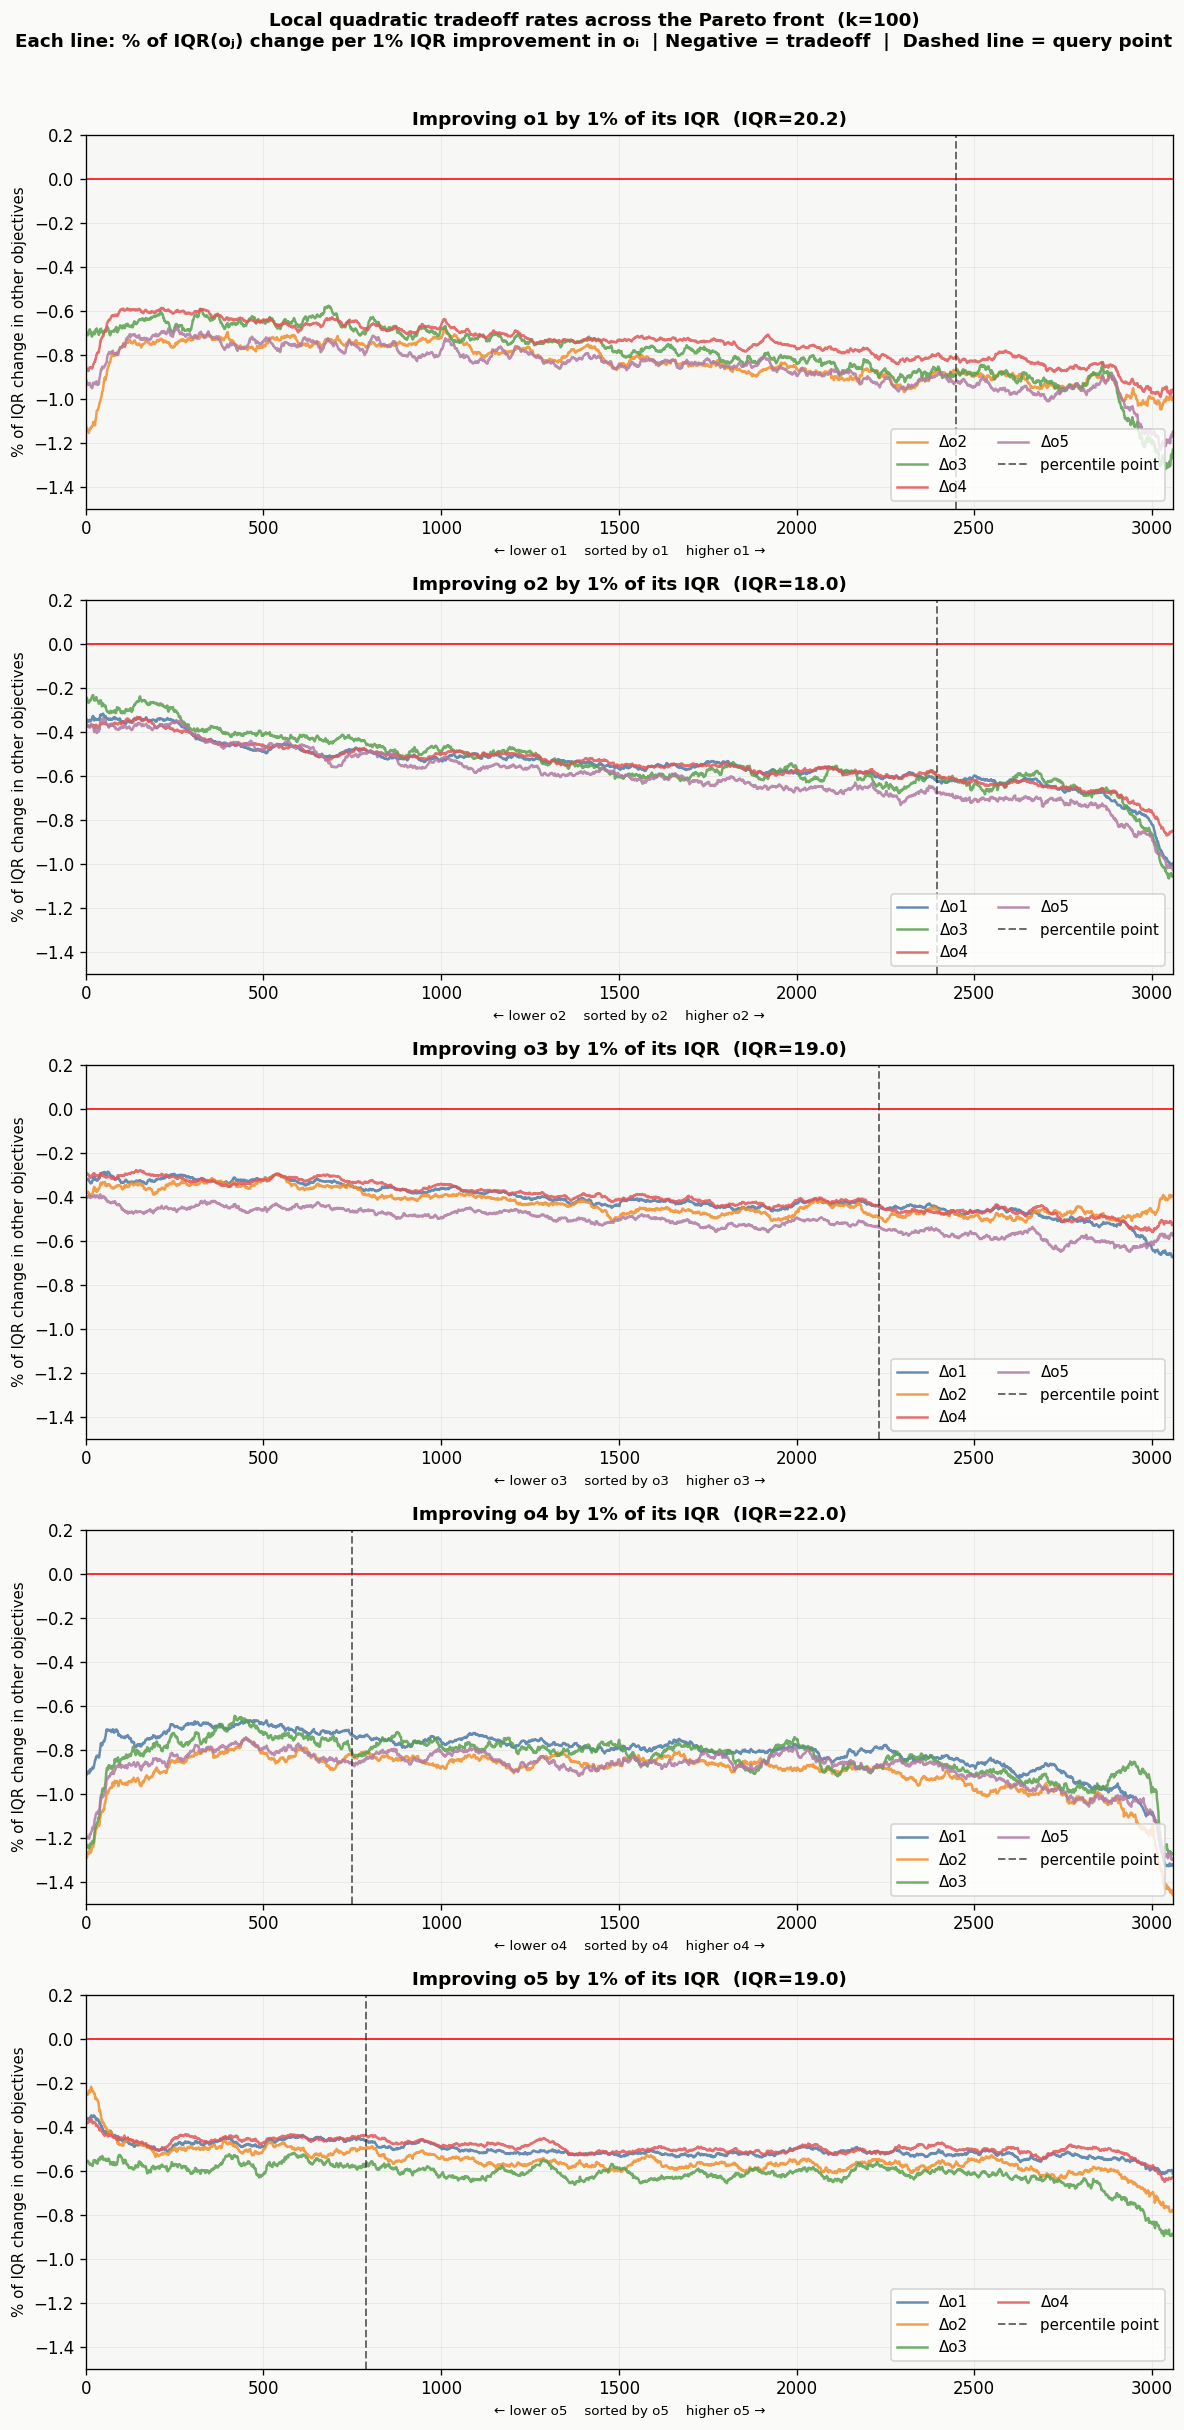

In [7]:
fig, axes = plt.subplots(d, 1, figsize=(10, 4 * d), facecolor="#FAFAF8", squeeze=False)
fig.suptitle(
    f"Local quadratic tradeoff rates across the Pareto front  (k={K})\n"
    "Each line: % of IQR(oⱼ) change per 1% IQR improvement in oᵢ  "
    "| Negative = tradeoff  |  Dashed line = query point",
    fontsize=11, fontweight="bold", y=1.01,
)
for i, ax in enumerate(axes[:, 0]):
    order     = np.argsort(data[:, i])
    x         = np.arange(N)
    query_pos = int(np.where(order == query_idx)[0][0])
    for j in range(d):
        if j == i: continue
        vals = uniform_filter1d(betas[order, i, j], size=SMOOTH)
        ax.plot(x, vals, color=OBJ_COLORS[j], lw=1.5, alpha=0.85,
                label=f"Δ{obj_names[j]}")
    ax.axhline(0, color="red", lw=1.2, alpha=0.8)
    ax.axvline(query_pos, color="#333333", lw=1.2, ls="--", alpha=0.7,
               label=f"{query_label} point")
    ax.set_ylim(-1.5, 0.2)
    ax.set_title(f"Improving {obj_names[i]} by 1% of its IQR  (IQR={iqr[i]:.1f})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel(
        f"← lower {obj_names[i]}    sorted by {obj_names[i]}    higher {obj_names[i]} →",
        fontsize=8)
    ax.set_ylabel("% of IQR change in other objectives", fontsize=9)
    ax.legend(fontsize=9, loc="lower right", ncol=2)
    ax.set_facecolor("#F7F7F5")
    ax.grid(True, lw=0.3, color="#DDDDDD")
    ax.set_xlim(0, N - 1)
plt.tight_layout()
plt.show()


## Bar Chart — MRS at Query Point

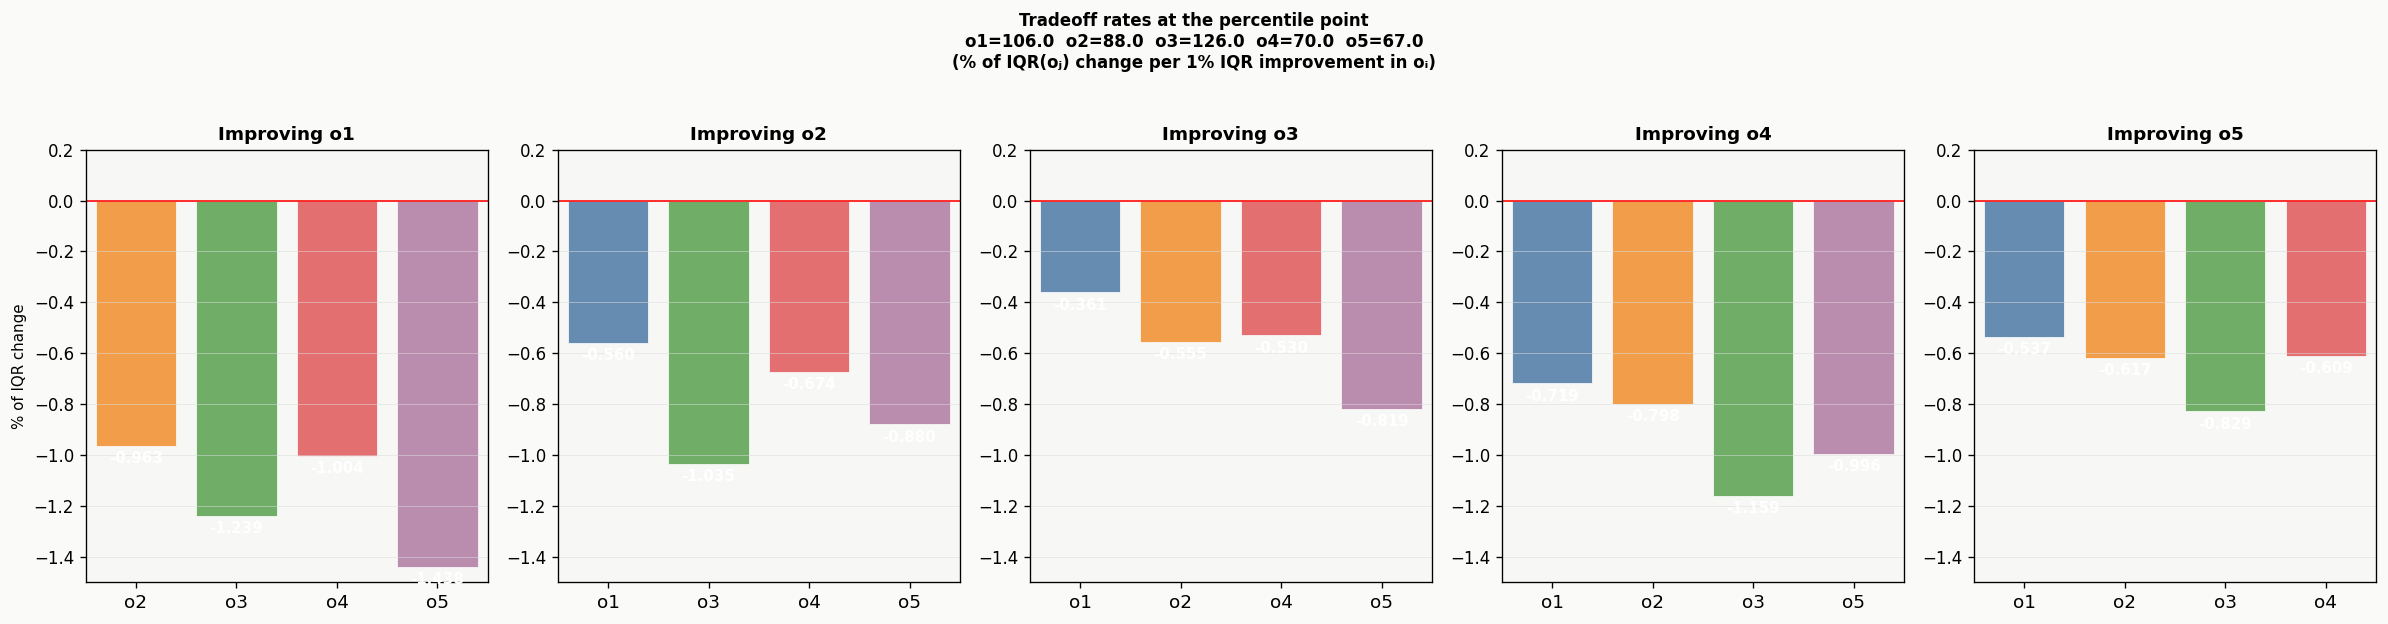

In [8]:
fig, axes = plt.subplots(1, d, figsize=(4 * d, 5), facecolor="#FAFAF8", squeeze=False)
fig.suptitle(
    f"Tradeoff rates at the {query_label} point\n"
    + "  ".join(f"{n}={v:.1f}" for n, v in zip(obj_names, query_pt))
    + "\n(% of IQR(oⱼ) change per 1% IQR improvement in oᵢ)",
    fontsize=10, fontweight="bold", y=1.03,
)
for i, ax in enumerate(axes[0]):
    others = [j for j in range(d) if j != i]
    vals   = [betas[query_idx, i, j] for j in others]
    bars   = ax.bar(np.arange(len(others)), vals,
                    color=[OBJ_COLORS[j] for j in others],
                    alpha=0.85, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val - 0.02,
                f"{val:.3f}", ha="center", va="top",
                fontsize=9, fontweight="bold", color="white")
    ax.axhline(0, color="red", lw=1.2, alpha=0.8)
    ax.set_xticks(np.arange(len(others)))
    ax.set_xticklabels([obj_names[j] for j in others], fontsize=11)
    ax.set_title(f"Improving {obj_names[i]}", fontsize=11, fontweight="bold")
    ax.set_ylabel("% of IQR change" if i == 0 else "", fontsize=9)
    ax.set_ylim(-1.5, 0.2)
    ax.set_facecolor("#F7F7F5")
    ax.grid(True, axis="y", lw=0.3, color="#DDDDDD")
    ax.set_xlim(-0.5, len(others) - 0.5)
plt.tight_layout()
plt.show()


## MRS Bar Chart Grid — sol_reweight runs

For every CSV under `data/pf/`, compute MRS at the query point (same
`PERCENTILE` / median rule as above) and arrange bar charts in a
**ref × temp** grid, matching `plot_ref_temp_grid` in
`test_sol_reweight_temp.ipynb`.

Each panel shows MRS when improving one objective (`improve_obj`).


In [ ]:
from pathlib import Path

K          = 100     # nearest neighbours for local regression
SMOOTH     = 80      # moving average window for line plots
EPSILON    = 0.10    # error tolerance for validity radius (0.10 = 10%)
PERCENTILE = None    # None = median (50th percentile of each objective)
OBJ_COLORS = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#B07AA1"]

def compute_mrs_at_query(data, k=K, percentile=PERCENTILE):
    """Fit local quadratic MRS only at the query point (fast)."""
    data = np.asarray(data, dtype=float)
    n, d_loc = data.shape
    iqr_loc = np.percentile(data, 75, axis=0) - np.percentile(data, 25, axis=0)
    iqr_loc = np.where(iqr_loc < 1e-12, 1.0, iqr_loc)

    if percentile is not None:
        target = np.array([
            np.percentile(data[:, i], p) for i, p in enumerate(percentile)
        ])
        query_label = "percentile"
    else:
        target = np.median(data, axis=0)
        query_label = "median"

    dists = np.abs((data - target) / iqr_loc).sum(axis=1)
    query_idx = int(np.argmin(dists))
    query_pt = data[query_idx]

    k_eff = min(k, n - 1)
    if k_eff < d_loc:
        raise ValueError(f"Need at least {d_loc + 1} points; got n={n}")

    nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(data / iqr_loc)
    _, nn_idx = nn.kneighbors((data[query_idx] / iqr_loc).reshape(1, -1))
    nbrs = data[nn_idx[0, 1:]] - data[query_idx]

    poly = PolynomialFeatures(degree=2, include_bias=True)
    mrs = np.zeros((d_loc, d_loc))
    for j in range(d_loc):
        input_cols = [c for c in range(d_loc) if c != j]
        X_poly = poly.fit_transform(nbrs[:, input_cols])
        coef, _, _, _ = np.linalg.lstsq(X_poly, nbrs[:, j], rcond=None)
        for pos, i in enumerate(input_cols):
            mrs[i, j] = coef[pos + 1] * iqr_loc[i] / iqr_loc[j]

    return mrs, query_pt, query_idx, query_label


def plot_mrs_bar_panel(ax, mrs, improve_obj, obj_names, obj_colors, ylim=None):
    """One MRS bar chart: improving `improve_obj`, bars = other objectives."""
    d_loc = len(obj_names)
    others = [j for j in range(d_loc) if j != improve_obj]
    vals = [mrs[improve_obj, j] for j in others]
    bars = ax.bar(
        np.arange(len(others)), vals,
        color=[obj_colors[j] for j in others],
        alpha=0.85, edgecolor="white", linewidth=0.5,
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val - 0.02 if val < 0 else val + 0.02,
            f"{val:.2f}",
            ha="center",
            va="top" if val < 0 else "bottom",
            fontsize=6,
            fontweight="bold",
            color="#333333",
        )
    ax.axhline(0, color="red", lw=1.0, alpha=0.8)
    ax.set_xticks(np.arange(len(others)))
    ax.set_xticklabels([obj_names[j] for j in others], fontsize=7)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_facecolor("#F7F7F5")
    ax.grid(True, axis="y", lw=0.3, color="#DDDDDD")
    ax.tick_params(axis="y", labelsize=7)


def plot_ref_temp_mrs_grid(
    improve_obj: int,
    *,
    trial_id: int = 8,
    pf_dir: Path = Path("data/pf"),
    percentiles: dict | None = None,
    temps: np.ndarray | None = None,
    k: int = K,
    percentile=PERCENTILE,
    ylim=(-1.5, 0.2),
    obj_names=None,
    obj_colors=None,
    save_path: Path | None = None,
):
    """Grid of MRS bar charts (rows=ref, cols=temp), one improving objective."""
    if percentiles is None:
        percentiles = {
            "qmax": np.array([100, 100, 100, 0, 0]),
            "qmin": np.array([0, 0, 0, 100, 100]),
            "qmedian": np.array([50, 50, 50, 50, 50]),
            "q95": np.array([95, 95, 95, 5, 5]),
            "q75": np.array([75, 75, 75, 25, 25]),
            "q60": np.array([60, 60, 60, 40, 40]),
            "q40": np.array([40, 40, 40, 60, 60]),
            "q25": np.array([25, 25, 25, 75, 75]),
            "q5": np.array([5, 5, 5, 95, 95]),
            "qsame": np.array([75, 75, 75, 75, 75]),
            "qoppo": np.array([95, 5, 5, 95, 5]),
            "qoppo2": np.array([95, 95, 5, 95, 5]),
        }
    if temps is None:
        temps = np.linspace(0.1, 1, 10)
    if obj_names is None:
        obj_names = [f"o{i}" for i in range(1, 6)]
    if obj_colors is None:
        obj_colors = OBJ_COLORS

    pf_dir = Path(pf_dir)
    ref_names = [
        name for name in percentiles
        if (pf_dir / f"ref{name}_temp{temps[0]:.1f}_trial{trial_id}.csv").exists()
    ]
    if not ref_names:
        raise FileNotFoundError(
            f"No CSVs found in {pf_dir} for trial {trial_id}"
        )

    n_rows, n_cols = len(ref_names), len(temps)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols * 2.4, n_rows * 2.4),
        squeeze=False,
        facecolor="#FAFAF8",
    )

    for i, name in enumerate(ref_names):
        for j, temp in enumerate(temps):
            csv_path = pf_dir / f"ref{name}_temp{temp:.1f}_trial{trial_id}.csv"
            ax = axes[i, j]
            if not csv_path.exists():
                ax.set_axis_off()
                ax.set_title("missing", fontsize=8, color="red")
                continue

            data_pf = pd.read_csv(csv_path).values.astype(float)
            mrs, query_pt, _, _ = compute_mrs_at_query(
                data_pf, k=k, percentile=percentile,
            )
            plot_mrs_bar_panel(
                ax, mrs, improve_obj, obj_names, obj_colors, ylim=ylim,
            )

            if i == 0:
                ax.set_title(f"temp={temp:.1f}", fontsize=9)
            if j == 0:
                ax.set_ylabel(f"{name}\n% IQR change", fontsize=8)
            if i == n_rows - 1:
                ax.set_xlabel(f"Improving {obj_names[improve_obj]}", fontsize=8)

    fig.suptitle(
        f"MRS at query point — improving {obj_names[improve_obj]} "
        f"(trial {trial_id})\n"
        f"(% of IQR(oⱼ) change per 1% IQR improvement)",
        y=1.02,
        fontsize=12,
    )
    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()
    return fig


# One grid per improving objective (0-indexed), trial 8 by default
trial_id = 8

for improve_obj in range(5):
    plot_ref_temp_mrs_grid(
        improve_obj,
        trial_id=trial_id,
        save_path=Path(
            f"data/pf/mrs_grid_improve_o{improve_obj + 1}_trial{trial_id}.png"
        ),
    )

## Validity Range of the Linear Prediction

In [9]:
nbrs_q = data[nn_indices[query_idx, 1:]] - data[query_idx]

radii_pct  = np.full((d, d), np.nan)
radii_raw  = np.full((d, d), np.nan)

for j in range(d):
    input_cols = [c for c in range(d) if c != j]
    feat_names = [f"x{p}" for p in range(len(input_cols))]
    X_poly     = poly.fit_transform(nbrs_q[:, input_cols])
    all_names  = list(poly.get_feature_names_out(feat_names))
    coef, _, _, _ = np.linalg.lstsq(X_poly, nbrs_q[:, j], rcond=None)

    for pos, i in enumerate(input_cols):
        b    = coef[pos + 1]
        c_ii = coef[all_names.index(f"x{pos}^2")]
        if abs(b) < 1e-8 or abs(c_ii) < 1e-10:
            radii_pct[i,j] = np.inf
            radii_raw[i,j] = np.inf
        else:
            dr = EPSILON * abs(b) / abs(c_ii)
            radii_raw[i,j] = dr
            radii_pct[i,j] = dr / iqr[i] * 100

print(f"Validity radii at {query_label} point  (ε={EPSILON:.0%})")
df_validity = pd.DataFrame(radii_pct.round(1), index=obj_names, columns=obj_names)
display(df_validity)


Validity radii at percentile point  (ε=10%)


,o1,o2,o3,o4,o5
o1,NaN,103.7,21.5,44.3,13.1
o2,26.4,NaN,28.0,39.6,37.7
o3,31.0,44.8,NaN,244.8,13.9
o4,93.5,343.6,21.7,NaN,21.1
o5,12.6,24.7,44.2,23.2,NaN


### Validity Heatmap

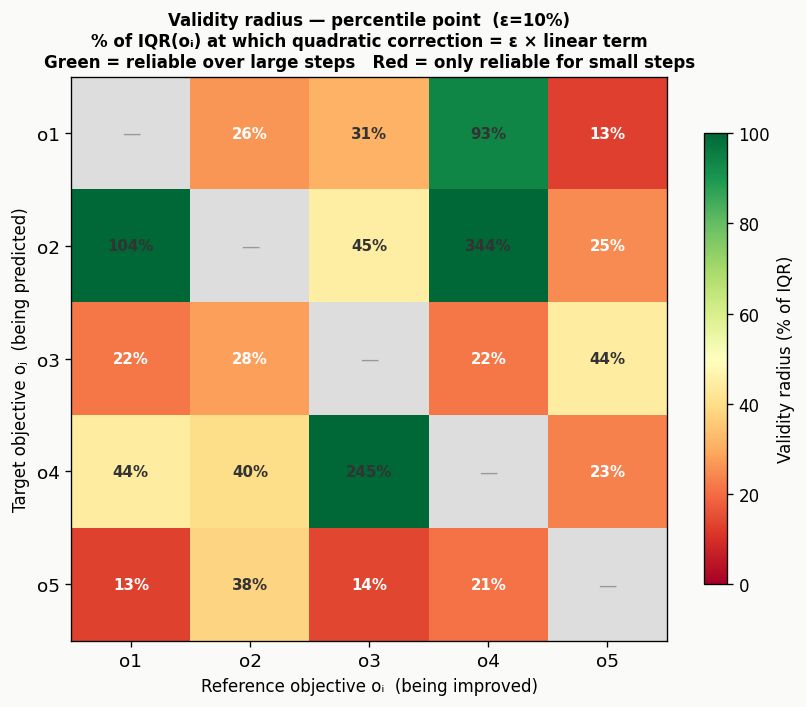

In [10]:
fig, ax = plt.subplots(figsize=(7, 6), facecolor="#FAFAF8")
display_r = np.where(np.isinf(radii_pct), 200,
            np.where(np.isnan(radii_pct), -1, radii_pct))
cmap = plt.cm.RdYlGn
cmap.set_under("#DDDDDD")
norm = mcolors.Normalize(vmin=0, vmax=100)
ax.imshow(display_r.T, cmap=cmap, norm=norm, aspect="auto")
for i in range(d):
    for j in range(d):
        if i == j:
            ax.text(i, j, "—", ha="center", va="center",
                    fontsize=11, color="#999999")
        else:
            val = radii_pct[i, j]
            txt = f"{val:.0f}%" if not np.isinf(val) else ">200%"
            ax.text(i, j, txt, ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if val < 30 else "#333333")
ax.set_xticks(range(d)); ax.set_xticklabels(obj_names, fontsize=11)
ax.set_yticks(range(d)); ax.set_yticklabels(obj_names, fontsize=11)
ax.set_xlabel("Reference objective oᵢ  (being improved)", fontsize=10)
ax.set_ylabel("Target objective oⱼ  (being predicted)", fontsize=10)
ax.set_title(
    f"Validity radius — {query_label} point  (ε={EPSILON:.0%})\n"
    "% of IQR(oᵢ) at which quadratic correction = ε × linear term\n"
    "Green = reliable over large steps   Red = only reliable for small steps",
    fontsize=10, fontweight="bold")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.8, label="Validity radius (% of IQR)")
plt.tight_layout()
plt.show()


### Validity Bar Chart

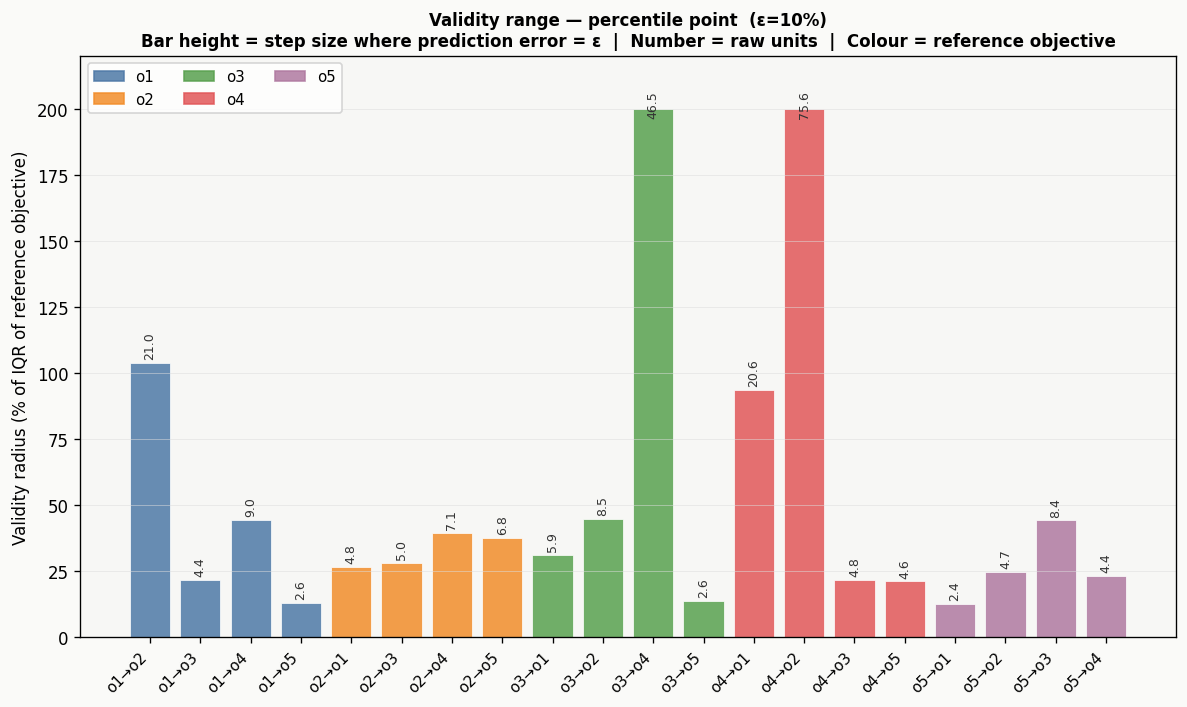

In [11]:
pct_vals, raw_vals, colors, labels = [], [], [], []
for i in range(d):
    for j in range(d):
        if i == j or np.isnan(radii_pct[i, j]): continue
        pct_vals.append(min(radii_pct[i, j], 200))
        raw_vals.append(min(radii_raw[i, j], 999))
        colors.append(OBJ_COLORS[i])
        labels.append(f"{obj_names[i]}→{obj_names[j]}")

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#FAFAF8")
bars = ax.bar(np.arange(len(pct_vals)), pct_vals, color=colors,
              alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, raw, pct in zip(bars, raw_vals, pct_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, min(pct, 195) + 1.5,
            f"{raw:.1f}" if raw < 999 else ">999",
            ha="center", va="bottom", fontsize=7.5,
            color="#333333", rotation=90)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Validity radius (% of IQR of reference objective)", fontsize=10)
ax.set_title(
    f"Validity range — {query_label} point  (ε={EPSILON:.0%})\n"
    "Bar height = step size where prediction error = ε  |  "
    "Number = raw units  |  Colour = reference objective",
    fontsize=10, fontweight="bold")
ax.set_ylim(0, 220)
ax.set_facecolor("#F7F7F5")
ax.grid(True, axis="y", lw=0.3, color="#DDDDDD")
handles = [Patch(color=OBJ_COLORS[i], alpha=0.85, label=obj_names[i])
           for i in range(d)]
ax.legend(handles=handles, fontsize=9, loc="upper left", ncol=3)
plt.tight_layout()
plt.show()


o1 -> o3: i = o1 (a column of X), j = o3 (Y)

If I improve o1 by 1% of its IQR, how much does o3 change, expressed as % of o3's IQR?